In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

plt.style.use("default")  

In [3]:

folder_path = "crop/"  

csv_files = glob.glob(folder_path + "*.csv")
print("Files found:", csv_files)

# Combine all CSVs
data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print("Combined dataset shape:", data.shape)

Files found: []


ValueError: No objects to concatenate

In [7]:
df.head()


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [8]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [11]:
df['Arrival_Date'] 
pd.to_datetime(df['Arrival_Date'], errors='coerce')
data = df.sort_values('Arrival_Date')
print(df['Arrival_Date'].min(), df['Arrival_Date'].max())

2025-01-01 2026-01-26


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 164959
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [13]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [14]:
df['Modal_Price'].describe()

count    5.984442e+06
mean     4.481359e+03
std      6.596095e+03
min      5.000000e-02
25%      2.040000e+03
50%      3.400000e+03
75%      5.500000e+03
max      4.000000e+06
Name: Modal_Price, dtype: float64

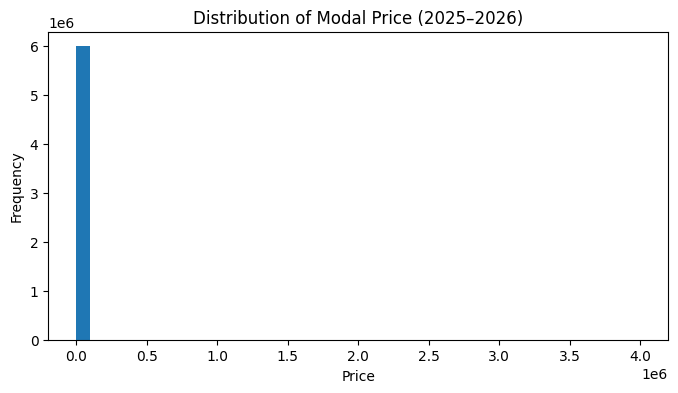

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(data['Modal_Price'], bins=40)
plt.title("Distribution of Modal Price (2025–2026)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [15]:
df['Modal_Price'].dtype

dtype('float64')

In [16]:
print(data['Modal_Price'].min())
print(data['Modal_Price'].max())
print(data['Modal_Price'].mean())
print(data['Modal_Price'].unique()[:20])  # first 20 unique values


print(data['Modal_Price'].value_counts().head(10))

0.05
4000000.0
4481.359241730085
[ 3500.    1100.    1500.    2600.    1000.    9500.   15500.   12500.
 15000.   11500.    1000.05  4000.    2500.     700.    2200.    1667.5
   900.    2000.    3700.    3800.  ]
Modal_Price
3000.0    312798
4000.0    303411
5000.0    221599
2000.0    211296
6000.0    201494
2500.0    200514
3500.0    170500
7000.0    120404
1500.0    118197
4500.0    110319
Name: count, dtype: int64


In [ ]:
top_crops = data['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [ ]:
df=data.copy()

In [ ]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 0


In [ ]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5984442, 11)


In [ ]:
df['Year']=df['Arrival_Date'].dt.year
print(df[['Arrival_Date','Year']].head())

      Arrival_Date  Year
0       2025-01-01  2025
10231   2025-01-01  2025
10232   2025-01-01  2025
10233   2025-01-01  2025
10234   2025-01-01  2025


In [ ]:
yearly_avg = df.groupby('Year')['Modal_Price'].mean()
print(yearly_avg)

Year
2025    4479.058924
2026    4568.598726
Name: Modal_Price, dtype: float64


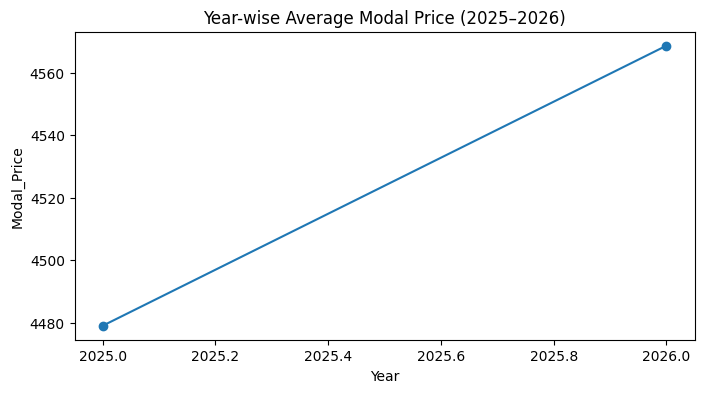

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Year-wise Average Modal Price (2025–2026)")
plt.xlabel("Year")
plt.ylabel("Modal_Price")
plt.show()

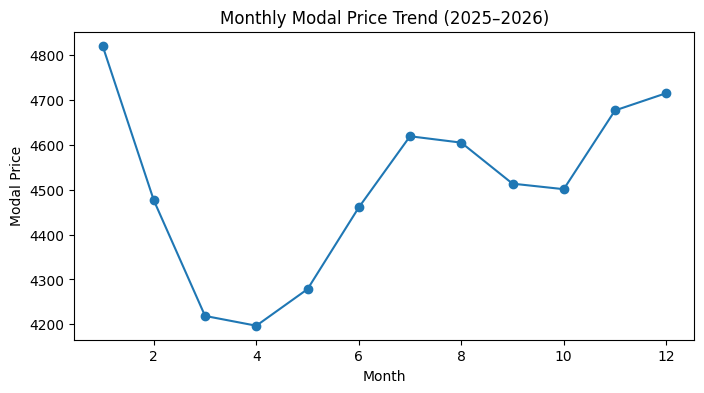

In [ ]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Modal_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Modal Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Modal Price")
plt.show()

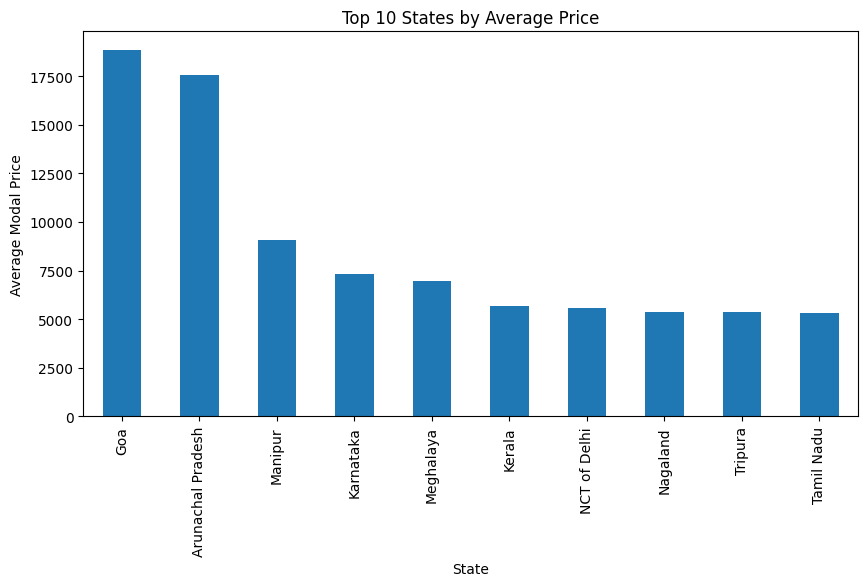

In [ ]:
state_avg = df.groupby('State')['Modal_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Modal Price")
plt.show()

In [ ]:
df['price_spread'] = df['Max_Price'] - df['Min_Price']
df['price_spread'].describe()

count    5.984442e+06
mean     6.969485e+02
std      2.245846e+03
min     -6.400000e+04
25%      1.000000e+02
50%      4.000000e+02
75%      7.100000e+02
max      8.484000e+05
Name: price_spread, dtype: float64

In [ ]:
df.to_csv("crop_25_26_combined.csv",index=False)

In [17]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_2025 = pd.read_csv(r"C:\Users\HP\Downloads\archive\csv\2025.csv")
df_2026 = pd.read_csv(r"C:\Users\HP\Downloads\archive\csv\2026.csv")


In [5]:
df = pd.concat([df__2025, df__2026])

df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


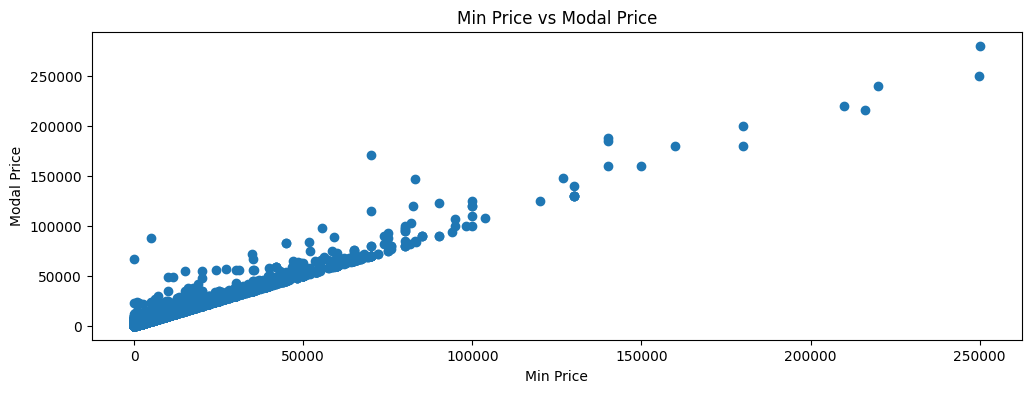

In [7]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.scatter(sample['Min_Price'], sample['Modal_Price'])
plt.xlabel("Min Price")
plt.ylabel("Modal Price")
plt.title("Min Price vs Modal Price")
plt.show()

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


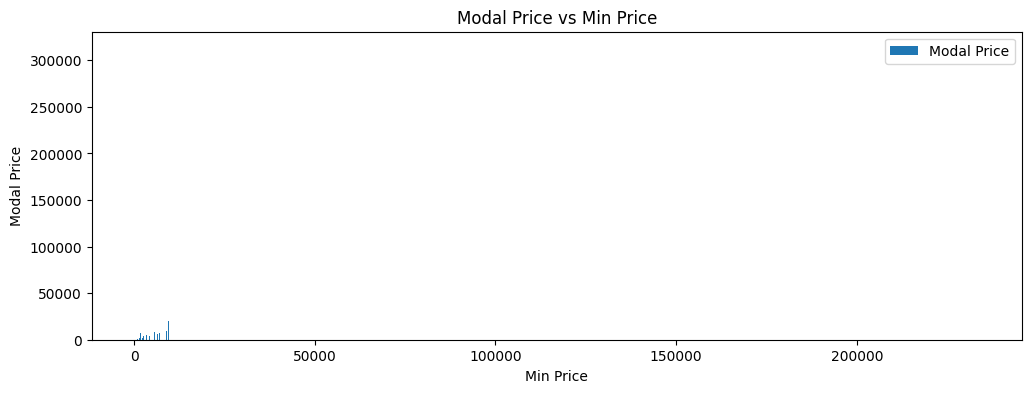

In [8]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.bar(sample['Min_Price'], sample['Modal_Price'], label='Modal Price')

plt.xlabel("Min Price")
plt.ylabel("Modal Price")
plt.title("Modal Price vs Min Price")

plt.legend()
plt.show()

In [19]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [20]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [21]:
X = df[['Min_Price','Max_Price']]
y = df['Modal_Price']

In [22]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
y_pred = model.predict(X_test)
y_pred

array([  817.17077725, 10682.13409276,  7651.55767819, ...,
        6348.70121065,  2792.24210277,  3610.78912543], shape=(1196889,))

In [52]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.987210633542386


In [48]:
print("R2 score: ",r2_score(y_test, y_pred))

R2 score:  0.99398132428444


In [28]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
2443315,2340.0,2436.538522
3925216,5000.0,5149.045777
2070299,2400.0,2480.367742
1819280,2225.0,2299.092885
5614526,5000.0,4864.635171


In [29]:
import pandas as pd
import numpy as np

In [3]:
df__2025=pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2025.csv")
df__2026=pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2026.csv")

In [30]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import gradio as gr
import numpy as np

In [32]:
import gradio as gr
import pandas as pd
import numpy as np

# 1. THE PREDICTION LOGIC
def predict_crop_price(state, district, market, commodity, variety):
    try:
        # Create a dictionary with keys matching your CSV column names EXACTLY
        # If your CSV used 'state' instead of 'State', change it here!
        input_dict = {
            'State': [state],
            'District': [district],
            'Market': [market],
            'Commodity': [commodity],
            'Variety': [variety]
        }
        
        # Convert to DataFrame for the model
        df = pd.DataFrame(input_dict)
        
        # Predict using your existing 'model' object
        prediction = model.predict(df)
        
        # Return formatted result
        return f"₹ {round(float(prediction[0]), 2)}"
    
    except NameError:
        return "Error: The variable 'model' is not found. Run your training cell first!"
    except Exception as e:
        return f"Error: {str(e)}"

# 2. THE UI LAYOUT
with gr.Blocks(theme=gr.themes.Default()) as demo:
    gr.Markdown("## 🌾 Crop Price Prediction Dashboard")
    
    with gr.Row():
        with gr.Column():
            st = gr.Textbox(label="State")
            dt = gr.Textbox(label="District")
            mk = gr.Textbox(label="Market")
            cm = gr.Textbox(label="Commodity")
            vt = gr.Textbox(label="Variety")
        
            
    predict_btn = gr.Button("Predict Modal Price", variant="primary")
    result_box = gr.Textbox(label="Prediction Result")

    # Link inputs to function
    predict_btn.click(
        fn=predict_crop_price,
        inputs=[st, dt, mk, cm, vt],
        outputs=result_box
    )

# 3. START THE APP
demo.launch(debug=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_5704\3532945722.py:33: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Default()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.
